In [ ]:
import pandas as pd

# Manually extracted from our Optuna output log
data = [
    {"Trial": 0, "LR": 6.39e-04, "Rank": 64,  "Dropout": 0.1,  "BLEU": 21.636},
    {"Trial": 1, "LR": 5.10e-04, "Rank": 128, "Dropout": 0.1,  "BLEU": 21.729}, # BEST
    {"Trial": 2, "LR": 6.95e-04, "Rank": 64,  "Dropout": 0.05, "BLEU": 21.533},
    {"Trial": 3, "LR": 4.17e-04, "Rank": 64,  "Dropout": 0.05, "BLEU": 21.142},
    {"Trial": 4, "LR": 3.20e-04, "Rank": 128, "Dropout": 0.1,  "BLEU": 21.677},
]

df = pd.DataFrame(data)
df

,Trial,LR,Rank,Dropout,BLEU
0,0,0.000639,64,0.10,21.636
1,1,0.000510,128,0.10,21.729
2,2,0.000695,64,0.05,21.533
3,3,0.000417,64,0.05,21.142
4,4,0.000320,128,0.10,21.677


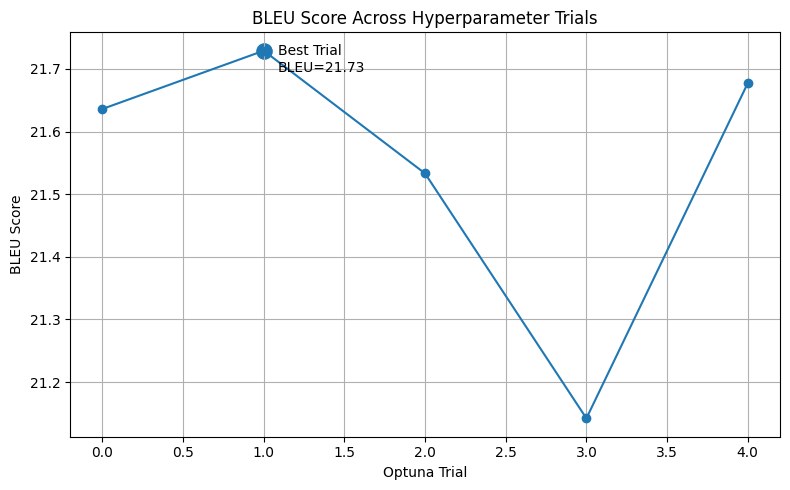

In [ ]:
# Plot 1: BLEU score per trial
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(df["Trial"], df["BLEU"], marker="o")
plt.xlabel("Optuna Trial")
plt.ylabel("BLEU Score")
plt.title("BLEU Score Across Hyperparameter Trials")
plt.grid(True)

# Highlight best trial
best = df.loc[df["BLEU"].idxmax()]
plt.scatter(best["Trial"], best["BLEU"], s=120)
plt.annotate(
    f"Best Trial\nBLEU={best['BLEU']:.2f}",
    (best["Trial"], best["BLEU"]),
    textcoords="offset points",
    xytext=(10, -15)
)

plt.tight_layout()
plt.show()

### Observation

* Trial 1 achieves the highest BLEU score among all configurations.

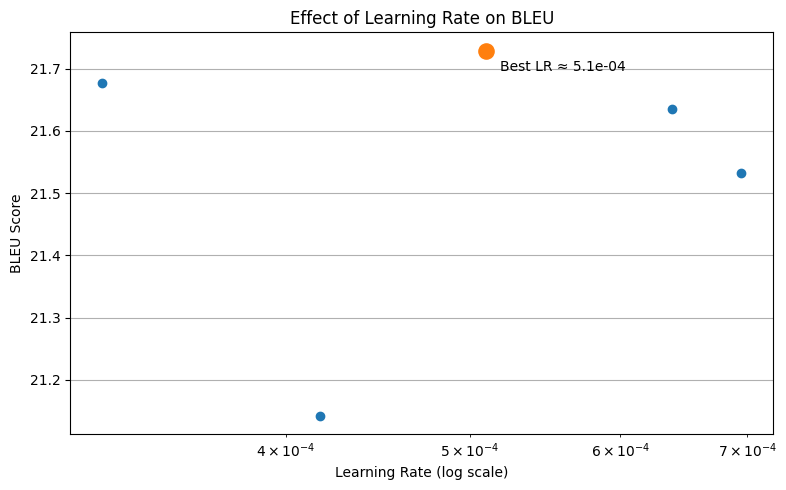

In [ ]:
# Plot 2: Learning Rate vs BLEU (log-scale)
plt.figure(figsize=(8, 5))
plt.scatter(df["LR"], df["BLEU"])
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("BLEU Score")
plt.title("Effect of Learning Rate on BLEU")
plt.grid(True)

# Annotate best LR
plt.scatter(best["LR"], best["BLEU"], s=120)
plt.annotate(
    f"Best LR ≈ {best['LR']:.1e}",
    (best["LR"], best["BLEU"]),
    textcoords="offset points",
    xytext=(10, -15)
)

plt.tight_layout()
plt.show()

### Observation

* Extremely high or low learning rates degrade BLEU; mid-range LR performs best.

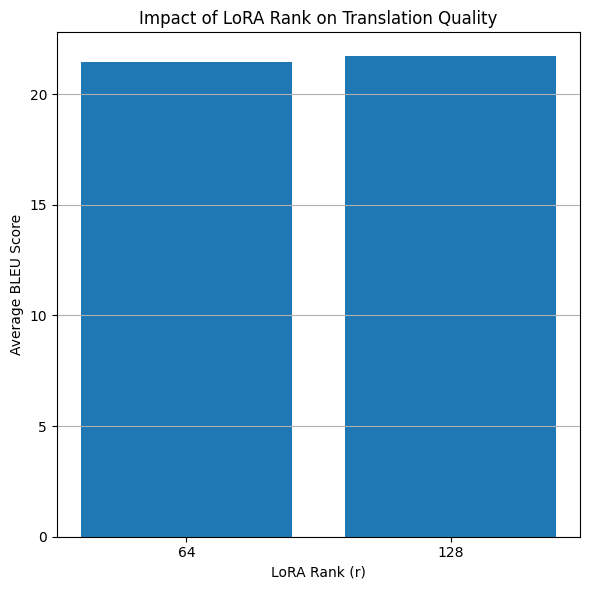

In [ ]:
# Plot 3: LoRA Rank vs BLEU
plt.figure(figsize=(6, 6))

rank_means = df.groupby("Rank")["BLEU"].mean()
plt.bar(rank_means.index.astype(str), rank_means.values)

plt.xlabel("LoRA Rank (r)")
plt.ylabel("Average BLEU Score")
plt.title("Impact of LoRA Rank on Translation Quality")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Observation

* Higher LoRA rank (128) consistently yields higher BLEU, indicating improved capacity.

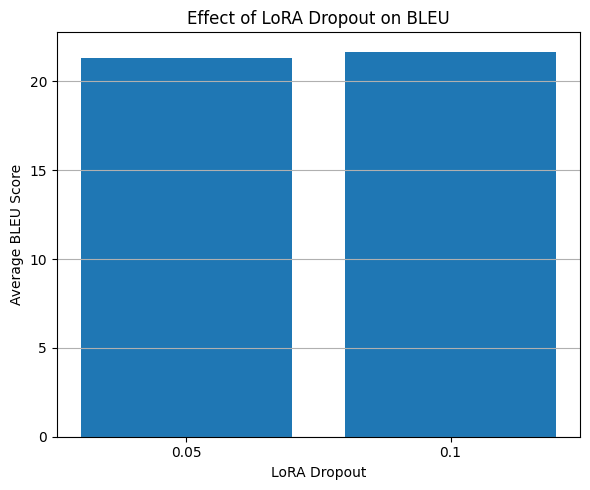

In [ ]:
# Plot 4: Dropout vs BLEU (regularization insight)
plt.figure(figsize=(6, 5))

dropout_means = df.groupby("Dropout")["BLEU"].mean()
plt.bar(dropout_means.index.astype(str), dropout_means.values)

plt.xlabel("LoRA Dropout")
plt.ylabel("Average BLEU Score")
plt.title("Effect of LoRA Dropout on BLEU")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Observation
* Dropout = 0.1 provides better regularization than 0.05 for this dataset.

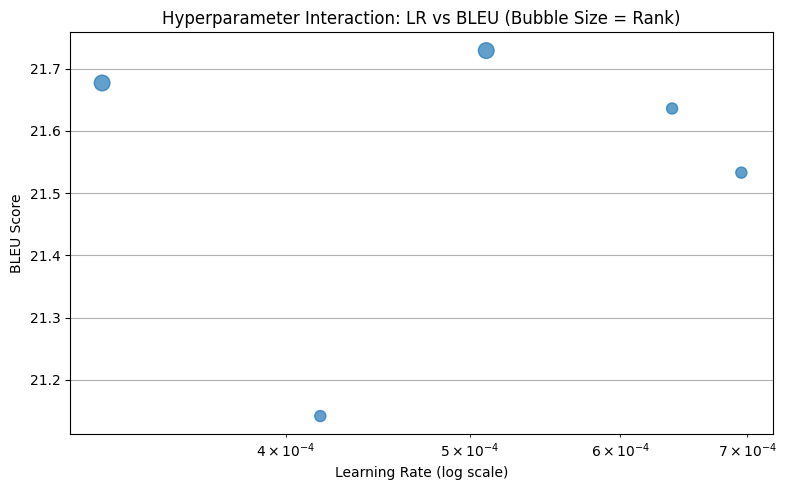

In [ ]:
# Combined Scatter
plt.figure(figsize=(8, 5))
plt.scatter(df["LR"], df["BLEU"], s=df["Rank"], alpha=0.7)
plt.xscale("log")

plt.xlabel("Learning Rate (log scale)")
plt.ylabel("BLEU Score")
plt.title("Hyperparameter Interaction: LR vs BLEU (Bubble Size = Rank)")
plt.grid(True)

plt.tight_layout()
plt.show()

## Single Comprehensive Plot

* Rows = trials
* Columns = metrics

### Final figure layout

Figure structure (5 × 3 grid):

* Column 1 : Training Loss (Epoch-wise)
* Column 2 : Validation Loss (Epoch-wise)
* Column 3 : BLEU (Epoch-wise)
* Rows = Trial 0 → Trial 4

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.0
)

# Epochs
epochs = [1, 2, 3]

# Trial-wise data
trials = {
    0: {
        "params": "LR=6.39e-04 | R=64 | D=0.1",
        "train": [1.4685, 1.2694, 1.0652],
        "val":   [1.3200, 1.2766, 1.2725],
        "bleu":  [19.36, 21.03, 21.64],
    },
    1: {
        "params": "LR=5.10e-04 | R=128 | D=0.1",
        "train": [1.4572, 1.2265, 0.9890],
        "val":   [1.3114, 1.2676, 1.2694],
        "bleu":  [19.76, 20.92, 21.73],
    },
    2: {
        "params": "LR=6.95e-04 | R=64 | D=0.05",
        "train": [1.4729, 1.2544, 1.0361],
        "val":   [1.3185, 1.2739, 1.2709],
        "bleu":  [19.56, 20.95, 21.53],
    },
    3: {
        "params": "LR=4.17e-04 | R=64 | D=0.05",
        "train": [1.4681, 1.3138, 1.1620],
        "val":   [1.3299, 1.2868, 1.2765],
        "bleu":  [19.30, 20.63, 21.14],
    },
    4: {
        "params": "LR=3.20e-04 | R=128 | D=0.1",
        "train": [1.4594, 1.2822, 1.1119],
        "val":   [1.3224, 1.2791, 1.2709],
        "bleu":  [19.49, 20.88, 21.68],
    },
}

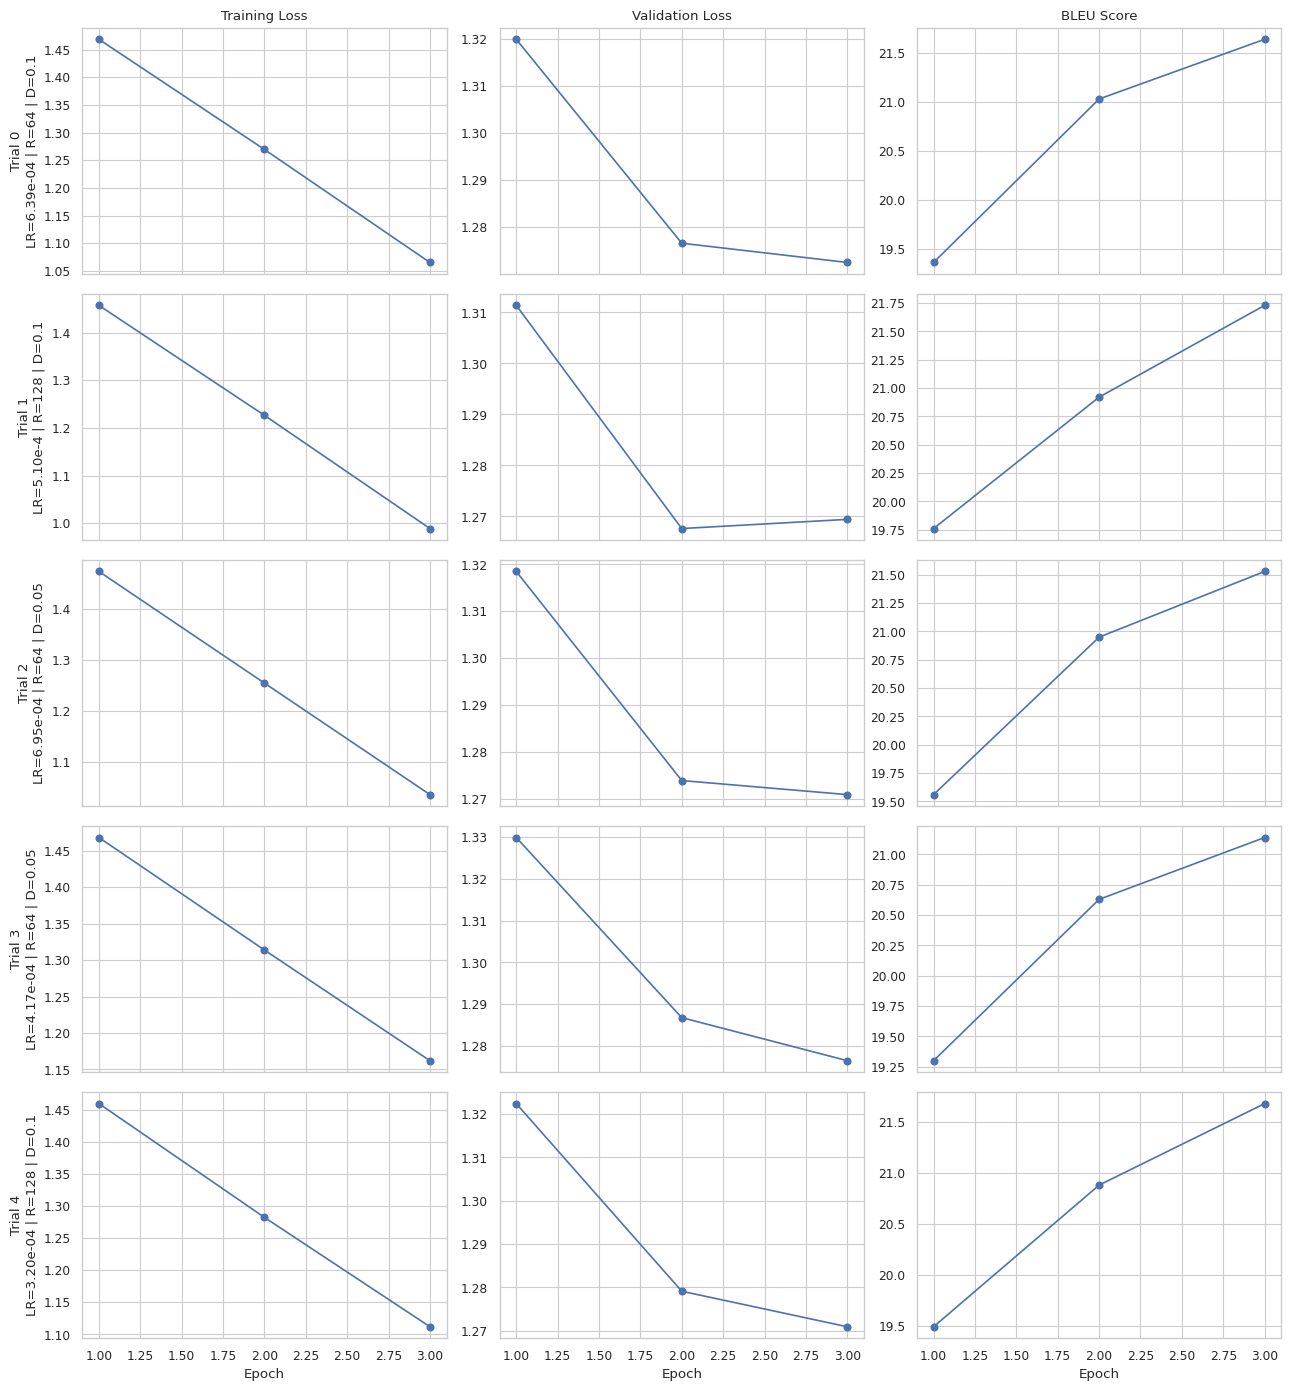

In [ ]:
# Create figure
fig, axes = plt.subplots(nrows=5,
                         ncols=3,
                         figsize=(13, 14),
                         sharex=True)

for row, (trial_id, data) in enumerate(trials.items()):
    axes[row, 0].plot(epochs, data["train"], marker="o")
    axes[row, 1].plot(epochs, data["val"], marker="o")
    axes[row, 2].plot(epochs, data["bleu"], marker="o")

    axes[row, 0].set_ylabel(f"Trial {trial_id}\n{data['params']}")

# Column titles
axes[0, 0].set_title("Training Loss")
axes[0, 1].set_title("Validation Loss")
axes[0, 2].set_title("BLEU Score")

# X-labels
for ax in axes[-1, :]:
    ax.set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [9]:
# Styling
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.1
)

# Data (from our Optuna logs)
epochs = [1, 2, 3]

trials = {
    "Trial 0 | LR=6.39e-04 | R=64 | D=0.1": {
        "val_loss": [1.3200, 1.2766, 1.2725],
        "bleu":     [19.36, 21.03, 21.64],
    },
    "Trial 1 ★ | LR=5.10e-04 | R=128 | D=0.1": {
        "val_loss": [1.3114, 1.2676, 1.2694],
        "bleu":     [19.76, 20.92, 21.73],
    },
    "Trial 2 | LR=6.95e-04 | R=64 | D=0.05": {
        "val_loss": [1.3185, 1.2739, 1.2709],
        "bleu":     [19.56, 20.95, 21.53],
    },
    "Trial 3 | LR=4.17e-04 | R=64 | D=0.05": {
        "val_loss": [1.3299, 1.2868, 1.2765],
        "bleu":     [19.30, 20.63, 21.14],
    },
    "Trial 4 | LR=3.20e-04 | R=128 | D=0.1": {
        "val_loss": [1.3224, 1.2791, 1.2709],
        "bleu":     [19.49, 20.88, 21.68],
    },
}

In [10]:
# Convert to long-format DataFrame
rows = []
for trial, metrics in trials.items():
    for i, ep in enumerate(epochs):
        rows.append({
            "Trial": trial,
            "Epoch": ep,
            "Validation Loss": metrics["val_loss"][i],
            "BLEU": metrics["bleu"][i],
        })

df_2 = pd.DataFrame(rows)

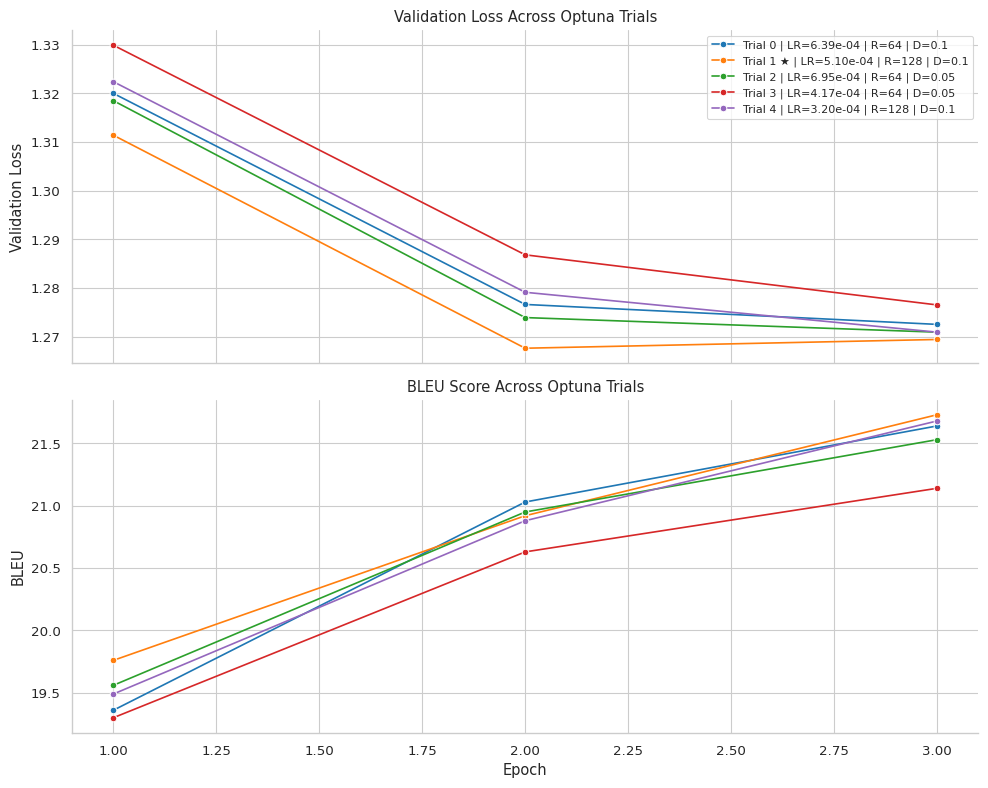

In [11]:
# Plot
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 8),
    sharex=True
)

palette = sns.color_palette("tab10", n_colors=len(trials))

# Validation Loss
sns.lineplot(
    data=df_2,
    x="Epoch",
    y="Validation Loss",
    hue="Trial",
    marker="o",
    ax=axes[0],
    palette=palette
)
axes[0].set_title("Validation Loss Across Optuna Trials")
axes[0].legend(loc="upper right", fontsize=8)

# BLEU
sns.lineplot(
    data=df_2,
    x="Epoch",
    y="BLEU",
    hue="Trial",
    marker="o",
    ax=axes[1],
    palette=palette,
    legend=False
)
axes[1].set_title("BLEU Score Across Optuna Trials")
axes[1].set_xlabel("Epoch")

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# plt.savefig("optuna_val_loss_bleu_comparison.pdf", bbox_inches="tight")